# Euclid and DESI Corresponding Data Encoding with AION

This notebook demonstrates loading **corresponding** Euclid+DESI pairs from the same dataset, encoding using AION codecs, generating embeddings, decoding specific batches, and visualizing with UMAP.

**Note**: Euclid images use HSCImage modality (tok_image_hsc) because the pretrained AION model was not trained on Euclid-specific tokens.

## Imports and Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from aion import AION
from aion.codecs import CodecManager
from aion.datasets import EuclidDESIDataset
from aion.modalities import HSCImage, DESISpectrum
from umap.umap_ import UMAP

CACHE_DIR = "../data/"
device = 'cpu'
print(f"Using device: {device}")

Using device: cpu


## Load Euclid+DESI Dataset (Corresponding Pairs)

This dataset returns tuples of (EuclidImage, DESISpectrum) from the same astronomical objects.

In [2]:
BATCH_SIZE = 1
BATCH_COUNT = 3

print("Loading Euclid+DESI dataset (corresponding pairs)...")
dataset = EuclidDESIDataset(
    cache_dir=CACHE_DIR,
    batch_size=BATCH_SIZE,
    batch_count=BATCH_COUNT,
    device=device
)

print(f"\nTotal samples: {len(dataset)}")
print(f"Number of batches: {(len(dataset) + BATCH_SIZE - 1) // BATCH_SIZE}")
print(f"Note: Euclid images will use HSC image codec (tok_image_hsc)")

Loading Euclid+DESI dataset (corresponding pairs)...
Loaded 3 samples from disk: ../data/euclid_desi_slice

Total samples: 3
Number of batches: 3
Note: Euclid images will use HSC image codec (tok_image_hsc)


## Initialize AION Model and Codec Manager

In [3]:
print("Loading AION model...")
model = AION.from_pretrained('polymathic-ai/aion-base').to(device)
print("Loading Codec Manager...")
codec_manager = CodecManager(device=device)
print("Model and codec manager loaded successfully")

Loading AION model...
Loading Codec Manager...
Model and codec manager loaded successfully


## Encode Corresponding Euclid+DESI Pairs → Embeddings

Process each batch: encode both modalities together, generate embeddings, and compute mean.

In [4]:
print("Processing Euclid+DESI batches...")
all_embeddings_list = []

for i, (euclid_batch, desi_batch) in enumerate(dataset):
    print(f"\nBatch {i+1}/{BATCH_COUNT}")
    print(f"  Euclid (as HSCImage): {euclid_batch.flux.shape}")
    print(f"  DESI: {desi_batch.flux.shape}")
    
    tokens = codec_manager.encode(euclid_batch, desi_batch)
    print(f"    Euclid tokens (tok_image_hsc): {tokens['tok_image_hsc'].shape}")
    print(f"    DESI tokens: {tokens['tok_spectrum_desi'].shape}")
    
    embeddings = model.encode(tokens)
    print(f"    Combined embeddings shape: {embeddings.shape}")
    
    avg_embeddings = embeddings.mean(dim=1)
    print(f"    Averaged shape: {avg_embeddings.shape}")
    
    all_embeddings_list.append(avg_embeddings.cpu().detach())

all_embeddings = torch.cat(all_embeddings_list, dim=0).numpy()
print(f"\nFinal combined embeddings shape: {all_embeddings.shape}")
print(f"Total samples: {all_embeddings.shape[0]} (Euclid+DESI corresponding pairs)")

Processing Euclid+DESI batches...

Batch 1/3
  Euclid (as HSCImage): torch.Size([1, 4, 160, 160])
  DESI: torch.Size([1, 7781])
    Euclid tokens (tok_image_hsc): torch.Size([1, 576])
    DESI tokens: torch.Size([1, 273])
    Combined embeddings shape: torch.Size([1, 256, 768])
    Averaged shape: torch.Size([1, 768])

Batch 2/3
  Euclid (as HSCImage): torch.Size([1, 4, 160, 160])
  DESI: torch.Size([1, 7781])


/home/wassim/Projects/NBody/AION/aion/datasets.py:281: RuntimeWarning: invalid value encountered in multiply
  mask = error * 0


    Euclid tokens (tok_image_hsc): torch.Size([1, 576])
    DESI tokens: torch.Size([1, 273])
    Combined embeddings shape: torch.Size([1, 256, 768])
    Averaged shape: torch.Size([1, 768])

Batch 3/3
  Euclid (as HSCImage): torch.Size([1, 4, 160, 160])
  DESI: torch.Size([1, 7781])
    Euclid tokens (tok_image_hsc): torch.Size([1, 576])
    DESI tokens: torch.Size([1, 273])
    Combined embeddings shape: torch.Size([1, 256, 768])
    Averaged shape: torch.Size([1, 768])

Final combined embeddings shape: (3, 768)
Total samples: 3 (Euclid+DESI corresponding pairs)


## Decode Specific Batch

Use indexing to select a specific batch, encode it, then decode back to Euclid images.

In [7]:
print("Selecting and decoding batch 0...")
entry = 0
euclid_batch, desi_batch = dataset[entry]

print(f"Batch shapes:")
print(f"  Euclid (as HSCImage): {euclid_batch.flux.shape}")
print(f"  DESI: {desi_batch.flux.shape}")
print(f"  Euclid bands: {euclid_batch.bands}")

tokens = codec_manager.encode(euclid_batch, desi_batch)
print(f"\nToken shapes:")
print(f"  Euclid tokens (tok_image_hsc): {tokens['tok_image_hsc'].shape}")
print(f"  DESI tokens: {tokens['tok_spectrum_desi'].shape}")

reconstructed_euclid = codec_manager.decode(
    tokens,
    HSCImage,
    bands=euclid_batch.bands,
)

print(f"\nReconstructed Euclid shape: {reconstructed_euclid.flux.shape}")

Selecting and decoding batch 0...
Batch shapes:
  Euclid (as HSCImage): torch.Size([1, 4, 160, 160])
  DESI: torch.Size([1, 7781])
  Euclid bands: ['EUCLID-VIS', 'EUCLID-Y', 'EUCLID-J', 'EUCLID-H']

Token shapes:
  Euclid tokens (tok_image_hsc): torch.Size([1, 576])
  DESI tokens: torch.Size([1, 273])

Reconstructed Euclid shape: torch.Size([1, 4, 96, 96])


## Visualize Original vs Reconstructed Euclid Images

Compare the first sample across all 4 Euclid bands (VIS, Y, J, H).

$x' = a*x{euclid} + b$  with 


$a = \frac{\sigma{HSC}}{\sigma{Euclid}}$ and $b = \mu{HSC} - a\mu_{euclid}$

In [ ]:
euclid_batch.flux.shape , reconstructed_euclid.flux.shape

(torch.Size([10, 4, 160, 160]), torch.Size([10, 4, 96, 96]))

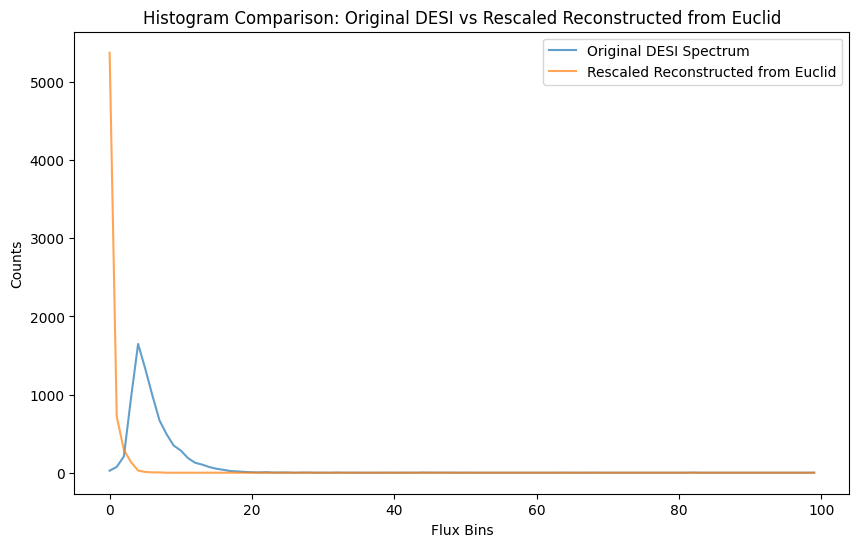

In [8]:
hist_of_original = torch.histc(desi_batch.flux, bins=100, min=0.0, max=desi_batch.flux.max())
hist_of_reconstructed = torch.histc(reconstructed_euclid.flux, bins=100, min=0.0, max=desi_batch.flux.max())
# NORMALIZE w.r.t to original image
a_factor = euclid_batch.flux.std() / reconstructed_euclid.flux.std()
b_factor = euclid_batch.flux.mean() - a_factor * reconstructed_euclid.flux.mean()
rescaled_reconstructed_flux = a_factor * reconstructed_euclid.flux + b_factor
hist_of_rescaled_reconstructed = torch.histc(rescaled_reconstructed_flux, bins=100, min=0.0, max=desi_batch.flux.max())

fig, ax = plt.subplots( figsize=(10, 6))
ax.plot(hist_of_original.numpy(), label='Original DESI Spectrum', alpha=0.7)
#ax.plot(hist_of_reconstructed.numpy(), label='Reconstructed from Euclid', alpha=0.7)
ax.plot(hist_of_rescaled_reconstructed.numpy(), label='Rescaled Reconstructed from Euclid', alpha=0.7)
ax.set_title('Histogram Comparison: Original DESI vs Rescaled Reconstructed from Euclid')
ax.set_xlabel('Flux Bins')
ax.set_ylabel('Counts')
ax.legend()
plt.show()




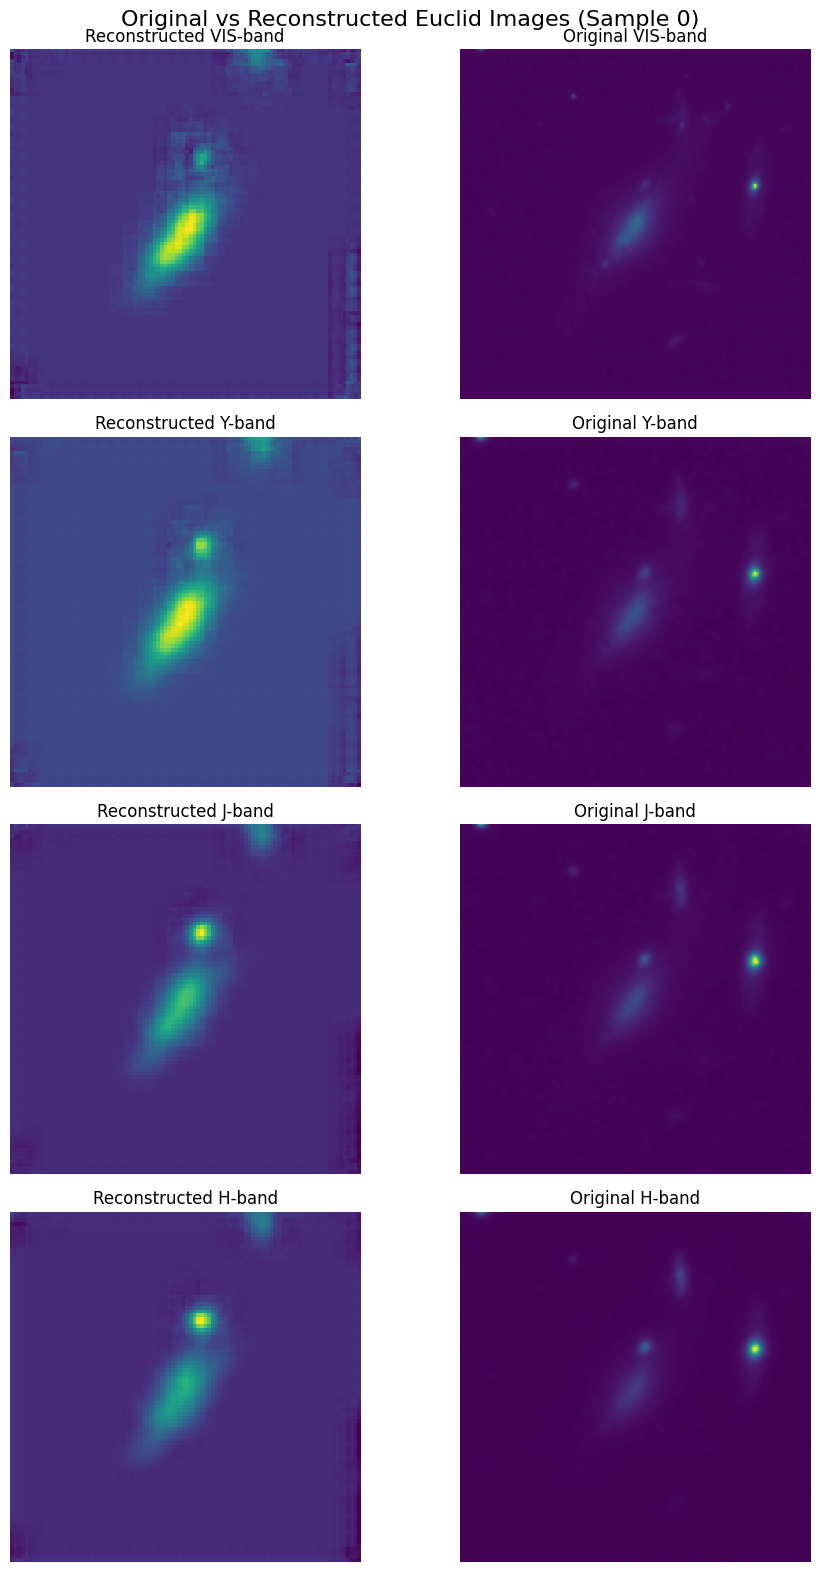

: 

In [ ]:
band_names = ['VIS', 'Y', 'J', 'H']

figure, axes = plt.subplots(4, 2, figsize=(10, 16))
figure.suptitle('Original vs Reconstructed Euclid Images (Sample 0)', fontsize=16)

euclid_batch , _ = dataset[entry]

for band_idx, band_name in enumerate(band_names):
    original = euclid_batch.flux[0, band_idx].cpu().detach().numpy()
    reconstructed = reconstructed_euclid.flux[0, band_idx].cpu().detach().numpy()
    
    axes[band_idx, 0].imshow(reconstructed, cmap='viridis')
    axes[band_idx, 0].set_title(f"Reconstructed {band_name}-band")
    axes[band_idx, 0].axis('off')
    
    axes[band_idx, 1].imshow(original, cmap='viridis')
    axes[band_idx, 1].set_title(f"Original {band_name}-band")
    axes[band_idx, 1].axis('off')

plt.tight_layout()
plt.show()

## UMAP Visualization

Reduce embeddings to 2D and visualize the distribution of Euclid+DESI pairs.

Total embeddings shape: (500, 768)
Samples: 500 Euclid+DESI corresponding pairs

Applying UMAP for 2D visualization...


/home/wassim/micromamba/envs/AAI11/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP reduced shape: (500, 2)


/tmp/ipykernel_31846/1694408623.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


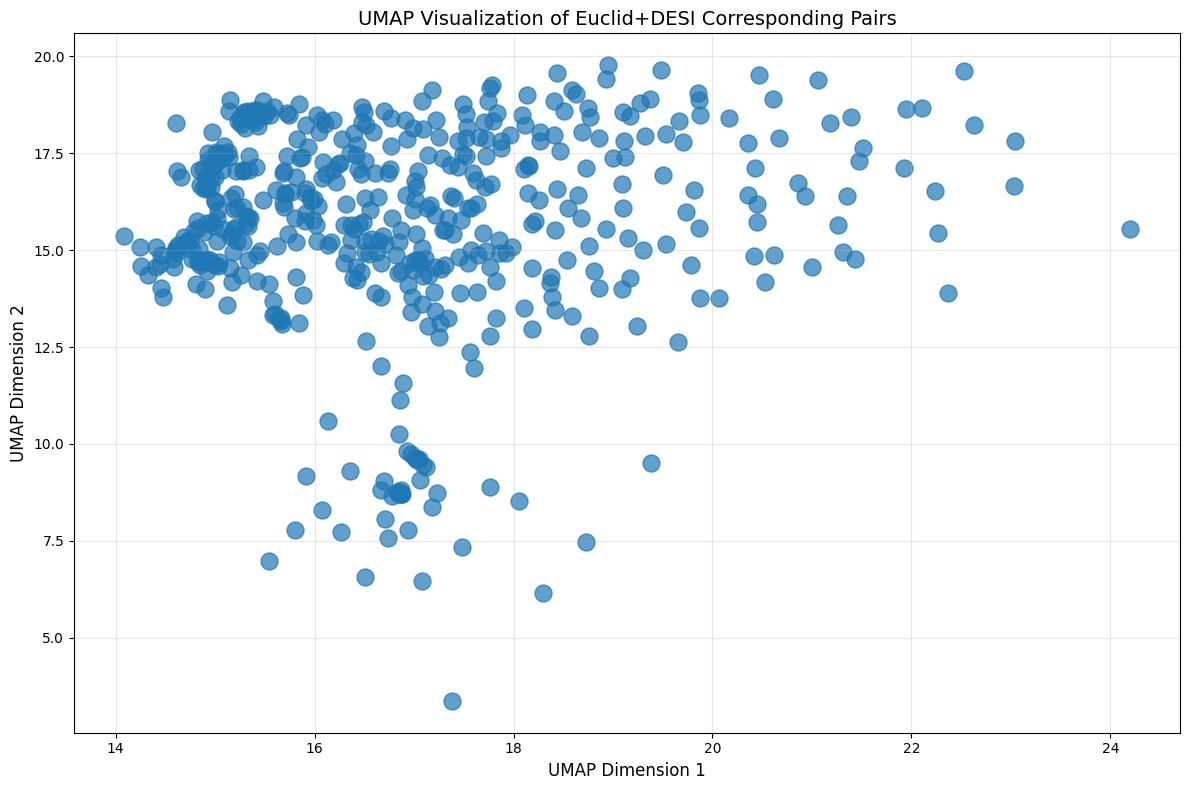


Original embedding dimension: 768
UMAP reduced dimension: 2


In [ ]:
print(f"Total embeddings shape: {all_embeddings.shape}")
print(f"Samples: {all_embeddings.shape[0]} Euclid+DESI corresponding pairs")

print("\nApplying UMAP for 2D visualization...")
reducer = UMAP(n_components=2, random_state=42,densmap=True)
embeddings_2d = reducer.fit_transform(all_embeddings)

print(f"UMAP reduced shape: {embeddings_2d.shape}")

plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0], 
    embeddings_2d[:, 1], 
    #c=range(len(embeddings_2d)),
    cmap='viridis',
    alpha=0.7,
    s=150
)
plt.xlabel('UMAP Dimension 1', fontsize=12)
plt.ylabel('UMAP Dimension 2', fontsize=12)
plt.title('UMAP Visualization of Euclid+DESI Corresponding Pairs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOriginal embedding dimension: {all_embeddings.shape[1]}")
print(f"UMAP reduced dimension: {embeddings_2d.shape[1]}")